In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [8]:
# 定义 Izhikevich 模型
def izhikevich(V, u, I, a, b, c, d, g=0.0, V_other=None):
    """
    Izhikevich 神经元模型的动态方程
    V: 膜电位
    u: 恢复变量
    I: 外部输入
    a, b, c, d: Izhikevich 模型的参数
    g: 耦合强度
    V_other: 与之耦合的另一个神经元的膜电位，默认为 None（无耦合）
    """
    dV = 0.04 * V**2 + 5 * V + 140 - u + I  # 膜电位的更新方程
    if V_other is not None:
        dV += g * (V_other - V)  # 耦合项
    du = a * (b * V - u)  # 恢复变量的更新方程

    V += dV
    u += du

    # 添加复位机制
    if V >= 30:  # 当膜电位超过阈值
        V = c     # 复位膜电位
        u += d    # 恢复变量增加

    return V, u


# 计算 Kuramoto 序参量，用于衡量同步性
def kuramoto_order_parameter(phases):
    """
    计算 Kuramoto 序参量
    :param phases: 神经元的相位列表
    :return: Kuramoto 序参量的值
    """
    r = np.sum(np.exp(1j * phases)) / len(phases)
    return np.abs(r)


# 模拟神经元网络
def simulate_neuron_network(G, T, dt, params, I, g, W):
    """
    模拟有向小世界网络中的神经元网络行为
    :param G: 网络结构
    :param T: 总时间
    :param dt: 时间步长
    :param params: 包含每个神经元的参数的字典
    :param I: 外部输入电流
    :param g: 耦合强度
    :param W: 传播权重矩阵
    :return: 神经元的膜电位和相位信息
    """
    N = len(G.nodes())
    V = np.full(N, -65.0, dtype=np.float64)  # 初始化膜电位
    u = np.full(N, 0.0, dtype=np.float64)  # 初始化恢复变量
    V[0] = 60
    V_hist = []
    phases = []
    steps = int(T / dt)
    for _ in range(steps):
        V_list = []
        for i in G.nodes():
            V_neighbors = []
            for j in G.predecessors(i):
                V_neighbors.append(W[j, i] * V[j])  # 考虑边的权重
            V_other = np.sum(V_neighbors) if V_neighbors else None
            a, b, c, d = params["a"][i], params["b"][i], params["c"][i], params["d"][i]
            V[i], u[i] = izhikevich(V[i], u[i], I[i], a, b, c, d, g, V_other)
            V_list.append(V[i])
        V_hist.append(V_list)
        phases.append([np.angle(np.exp(1j * V)) for V in V_list])
    return np.array(V_hist), np.array(phases)


# 主要函数，寻找合适的耦合参数
def find_coupling_parameter():
    """
    寻找合适的耦合参数，通过逐步增加耦合强度并计算 Kuramoto 序参量
    """
    T = 1000  # 总时间
    dt = 0.1  # 时间步长
    gs = np.linspace(0, 1.5, 10)  # 不同的耦合强度
    sync_indexes = []
    for g in gs:
        _, phases = simulate_neuron_network(G, T, dt, params, I, g, W)
        sync_index = kuramoto_order_parameter(phases[-1])  # 使用最后时刻的相位计算同步指数
        sync_indexes.append(sync_index)
    return gs, np.array(sync_indexes)


# 寻找耦合参数并绘制同步指数随耦合强度的变化
def plot_sync_index_vs_coupling():
    """
    绘制同步指数随耦合强度的变化曲线
    """
    gs, sync_indexes = find_coupling_parameter()
    plt.figure()
    plt.plot(gs, sync_indexes)
    plt.xlabel('Coupling strength (g)')
    plt.ylabel('Kuramoto Order Parameter')
    plt.title('Sync Index vs Coupling Strength')
    plt.show()


# 创建有向小世界网络
def create_directed_small_world_network():
    """
    创建有向小世界网络并设置初始条件
    """
    N = 100  # 节点数量
    k = 3  # 每个节点的固定出向边数量
    G = nx.DiGraph()
    G.add_nodes_from(range(N))
    np.random.seed(42)
    # 确保每个节点有 6 个唯一的出向边
    for node in range(N):
        targets = np.random.choice([n for n in range(N) if n!= node], k, replace=False)
        for target in targets:
            G.add_edge(node, target)
    # 为每个节点分配三维坐标，使得相邻节点尽可能靠近
    layout = nx.spring_layout(G, dim=3, seed=42)  # 使用 spring layout 生成 3D 坐标
    pos = {i: layout[i] for i in range(N)}
    # 初始化膜电位和恢复变量
    V = np.full(N, -65.0, dtype=np.float64)  # 初始膜电位为-65 mV
    V[0] = 60
    u = np.full(N, 0.0, dtype=np.float64)  # 初始恢复变量为0
    # 随机化每个神经元的模型参数
    params = {
        "a": np.random.uniform(0.01, 0.03, N),
        "b": np.random.uniform(0.1, 0.3, N),
        "c": np.random.uniform(-70, -60, N),
        "d": np.random.uniform(2, 10, N),
    }
    # 设置随机输入，初始仅对一个节点施加强刺激
    I = np.zeros(N)
    I[0] = 150  # 增强初始输入强度，确保刺激传播
    # 创建传播权重矩阵（固定随机权重）
    W = np.zeros((N, N))
    for i, j in G.edges():
        W[i, j] = np.random.uniform(0.8, 1.2)  # 权重在 0.8 到 1.2 之间波动
    return G, params, I, W

/tmp/ipykernel_980515/433501392.py:12: RuntimeWarning: overflow encountered in scalar power
  dV = 0.04 * V**2 + 5 * V + 140 - u + I  # 膜电位的更新方程
/tmp/ipykernel_980515/433501392.py:12: RuntimeWarning: overflow encountered in scalar multiply
  dV = 0.04 * V**2 + 5 * V + 140 - u + I  # 膜电位的更新方程
/tmp/ipykernel_980515/433501392.py:12: RuntimeWarning: invalid value encountered in scalar add
  dV = 0.04 * V**2 + 5 * V + 140 - u + I  # 膜电位的更新方程
/tmp/ipykernel_980515/433501392.py:14: RuntimeWarning: invalid value encountered in scalar add
  dV += g * (V_other - V)  # 耦合项
/tmp/ipykernel_980515/433501392.py:70: RuntimeWarning: invalid value encountered in exp
  phases.append([np.angle(np.exp(1j * V)) for V in V_list])
/tmp/ipykernel_980515/433501392.py:64: RuntimeWarning: overflow encountered in scalar multiply
  V_neighbors.append(W[j, i] * V[j])  # 考虑边的权重
/tmp/ipykernel_980515/433501392.py:14: RuntimeWarning: overflow encountered in scalar multiply
  dV += g * (V_other - V)  # 耦合项


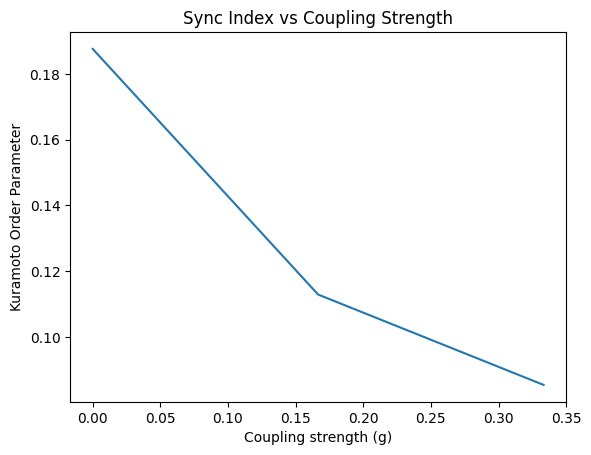

In [9]:
# 主程序
if __name__ == "__main__":
    G, params, I, W = create_directed_small_world_network()
    plot_sync_index_vs_coupling()